# NB2 - Exploratory Data Analysis

In [2]:
# Import the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [3]:
# Load the dataset
df = pd.read_csv("C:/Projects/13_Waste_to_energy_Analytics_Platform/data/cleaned_waste_management.csv")
df.head()

,countries,total_collected_msw_(t),food,garden,paper,plastic,glass,metal,rubber_and_leather,textile,other,scenario,co₂_emissions_reduction_potential
0,Algeria,9.372439e+06,54.4,1.5,9.8,16.9,1.2,2.8,12.6,0.0,0.8,Compost organics,-0.468069
1,Algeria,9.372439e+06,54.4,1.5,9.8,16.9,1.2,2.8,12.6,0.0,0.8,Digest organics,-0.468069
2,Algeria,9.372439e+06,54.4,1.5,9.8,16.9,1.2,2.8,12.6,0.0,0.8,Retrofit landfill,-0.463089
3,Algeria,9.372439e+06,54.4,1.5,9.8,16.9,1.2,2.8,12.6,0.0,0.8,Half waste,-0.500000
4,Algeria,9.372439e+06,54.4,1.5,9.8,16.9,1.2,2.8,12.6,0.0,0.8,Compost + retrofit,-0.674354


In [4]:
df['scenario'].value_counts()

scenario
Compost organics       43
Digest organics        43
Retrofit landfill      43
Half waste             43
Compost + retrofit     43
Digest + retrofit      43
All strategies (D)     43
All strategies (C)     22
All strategies (C)     21
Name: count, dtype: int64

## Category Normalization

In [5]:
print(df['scenario'].unique())

['Compost organics' 'Digest organics' 'Retrofit landfill' 'Half waste'
 'Compost + retrofit' 'Digest + retrofit' 'All strategies (C)'
 'All strategies (D)' 'All strategies (C) ']


In [7]:
df['scenario'] = df['scenario'].str.strip()

In [8]:
df['scenario'].value_counts()

scenario
Compost organics      43
Digest organics       43
Retrofit landfill     43
Half waste            43
Compost + retrofit    43
Digest + retrofit     43
All strategies (C)    43
All strategies (D)    43
Name: count, dtype: int64

## 1. Top 10 countries by Waste Generation

In [19]:
import plotly.express as px

# Get top 10
top_10 = df.groupby('countries')['total_collected_msw_(t)'].sum().sort_values(ascending=False).head(10).reset_index()

fig = px.bar(top_10, x='total_collected_msw_(t)', y='countries', orientation='h', 
             title='Top 10 Waste Generating Countries', color='total_collected_msw_(t)')
fig.show()

### Waste Collection by Country

To begin the EDA, I examined the **Total Collected Municipal Solid Waste (MSW)** across countries.  
This visualization highlights differences in waste generation and provides context for later scenario analysis.

### Key Observations
- The **United States** shows the highest total collected MSW, exceeding 2 billion tons.  
- **India** and **China** follow closely, reflecting their large populations and consumption patterns.  
- Countries like **Mexico** and **France** report significantly lower totals, suggesting differences in waste management systems and reporting.  
- The color scale (dark blue → bright yellow) emphasizes magnitude, making it easy to spot high-waste nations at a glance.

### Why This Matters
Understanding baseline waste volumes is crucial before analyzing scenario impacts (e.g., composting, retrofitting landfills).  
It sets the stage for comparing **CO₂ emissions reduction potential** across strategies and countries.


## 2. Waste Composition Breakdown

In [13]:
# Calculate mean of all composition columns
composition = df[['food', 'garden', 'paper', 'plastic', 'glass', 'metal']].mean()

fig = px.pie(values=composition.values, names=composition.index, 
             title='Average Global Waste Composition')
fig.show()



### Purpose
This pie chart shows the proportion of different waste types worldwide.

### Key Observations
- **Food waste** dominates at ~56%, highlighting its global impact.
- **Paper (16.5%)** and **plastic (14.2%)** are the next largest categories.
- Glass, garden, and metal waste each contribute less than 5%.

### Why It Matters
Identifying the largest waste streams helps prioritize strategies (e.g., composting food waste) for maximum environmental benefit.


## 3. CO₂ Potential vs. Total Waste

In [15]:
fig = px.scatter(df, x='total_collected_msw_(t)', y='co₂_emissions_reduction_potential', 
                 color='countries', title='Waste Volume vs. CO₂ Reduction Potential',
                 trendline="ols")
fig.show()



### Purpose
This scatter plot compares total collected municipal solid waste (MSW) with the potential reduction in CO₂ emissions across countries.

### Key Observations
- Most countries cluster near lower MSW volumes, with CO₂ reduction potentials ranging between 0 and -0.8.  
- Larger waste producers (e.g., United States, China, India) show distinct positions on the x-axis, reflecting their scale of waste generation.  
- Variation in CO₂ reduction potential suggests that strategies differ in effectiveness across nations, even with similar waste volumes.

### Why It Matters
This visualization highlights the relationship between waste generation and environmental impact, helping identify which countries could achieve the greatest CO₂ reductions through improved waste management strategies.


## 4. Correaltion HeatMap

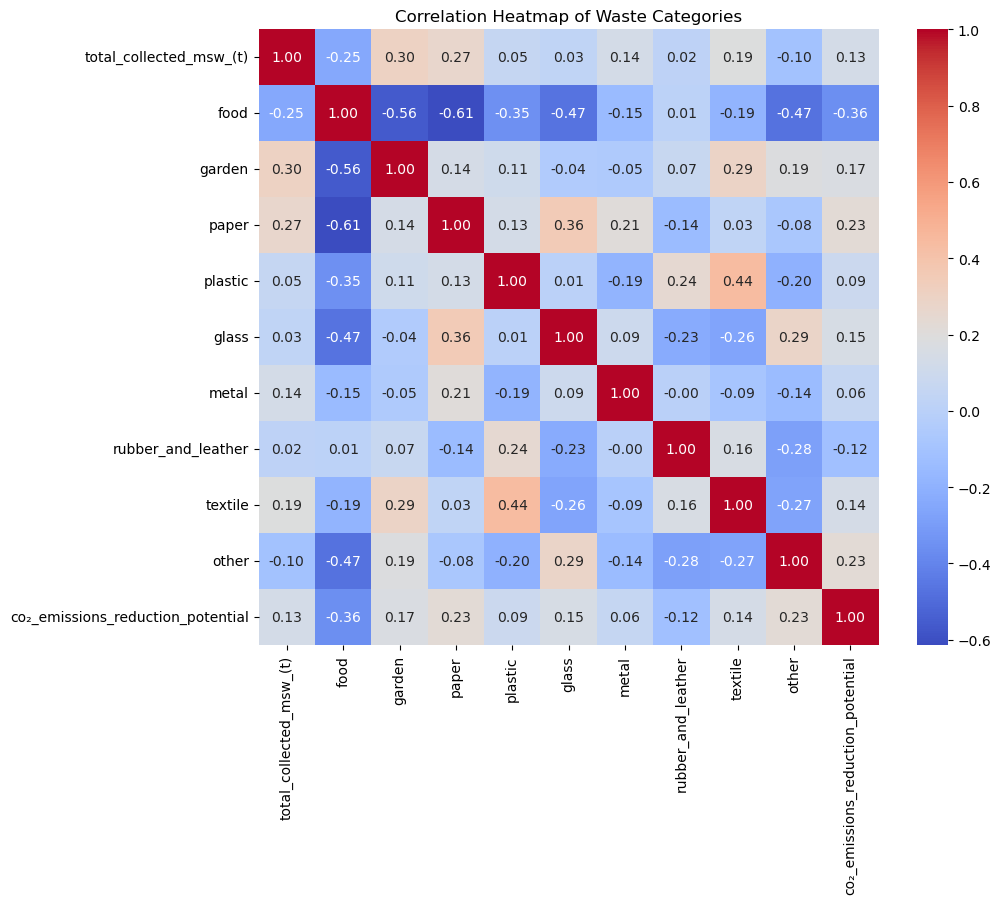

In [16]:
# Drop categorical columns for the heatmap
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Waste Categories")
plt.show()



### Purpose
This heatmap shows the correlations between different waste types and CO₂ emissions reduction potential.

### Key Observations
- Strong positive correlations exist among related waste categories (e.g., food and garden).  
- Some materials (like paper and plastic) show moderate relationships with CO₂ reduction potential.  
- Negative correlations highlight categories where higher values may reduce the effectiveness of emission strategies.

### Why It Matters
By identifying which waste streams are most linked to CO₂ reduction, this analysis helps prioritize strategies that maximize environmental benefits.


## 5. Geographic Distribution

In [17]:
fig = px.choropleth(df, 
                    locations="countries", 
                    locationmode="country names",
                    color="total_collected_msw_(t)",
                    title="Global Waste Generation Intensity",
                    color_continuous_scale=px.colors.sequential.Plasma)
fig.show()


### Purpose
This map illustrates the intensity of municipal solid waste (MSW) generation across countries.

### Key Observations
- Countries like the **United States** and **China** show the highest waste generation, highlighted in brighter colors.  
- Many regions are shaded darker, indicating lower waste volumes.  
- The geographic view makes it easy to compare waste intensity across continents.

### Why It Matters
Mapping waste generation provides a global perspective, helping identify regions where waste management strategies could have the greatest environmental impact.


## 6. CO₂ Reduction by Scenario

In [21]:
scenario_co2 = (
    df.groupby('scenario')['co₂_emissions_reduction_potential']
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

fig = px.bar(
    scenario_co2,
    x='scenario',
    y=scenario_co2['co₂_emissions_reduction_potential'].abs(),
    title='Average CO₂ Reduction Potential by Scenario'
)

fig.show()



### Purpose
This bar chart compares the average CO₂ emissions reduction potential across different waste management strategies.

### Key Observations
- All strategies show **negative values**, reflecting reductions in emissions.  
- Combined approaches (e.g., **Compost + retrofit**, **Digest + retrofit**) achieve greater reductions than single strategies.  
- Comprehensive strategies (**All strategies (C/D)**) deliver the largest average reduction potential.

### Why It Matters
This comparison highlights which waste management strategies are most effective, guiding decisions toward approaches that maximize environmental benefits.


## Key Findings from EDA

- **Scale of waste**: The United States, India, and China generate the largest volumes of municipal solid waste, while countries like Mexico and France produce comparatively less.  
- **Composition**: Food waste dominates globally (~56%), followed by paper and plastic, making organic waste the most critical stream to address.  
- **Relationships**: Scatter plots and correlations show that higher waste volumes do not always translate to greater CO₂ reduction potential — effectiveness depends on the chosen strategy.  
- **Global perspective**: Mapping waste intensity highlights regions where interventions could have the greatest impact, especially in high-waste nations.  
- **Scenario effectiveness**: Combined and comprehensive strategies (Compost + Retrofit, Digest + Retrofit, All Strategies C/D) consistently deliver the largest reductions in CO₂ emissions.  

### Overall Insight
The analysis reveals that tackling **food waste** and adopting **integrated strategies** are the most promising paths for maximizing CO₂ reduction. Countries with the highest waste volumes stand to benefit most from targeted interventions, making scenario choice a critical factor in global sustainability efforts.
